<a href="https://colab.research.google.com/github/Praisy123-166/credit-card-fraud-detection/blob/main/credit-card-fraud-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [13]:
df = pd.read_csv('creditcard.csv')
print("Dataset shape:", df.shape)
print("\nFraud vs Normal transactions:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.3f}%")

Dataset shape: (284807, 31)

Fraud vs Normal transactions:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


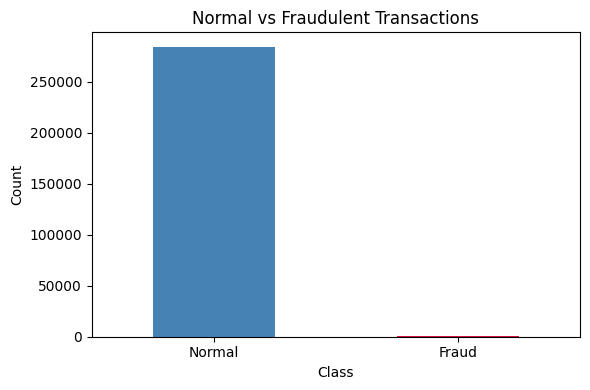

In [14]:
plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar', color=['steelblue','crimson'])
plt.title('Normal vs Fraudulent Transactions')
plt.xticks([0,1], ['Normal', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [15]:
# Scale the Amount column (other columns are already scaled)
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df = df.drop(columns=['Time', 'Amount'])

# Split features and target
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 227845
Test samples: 56962


In [16]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [19]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Fraud']))

auc = roc_auc_score(y_test, y_prob)
print(f"\nAUC Score: {auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962


AUC Score: 0.9528


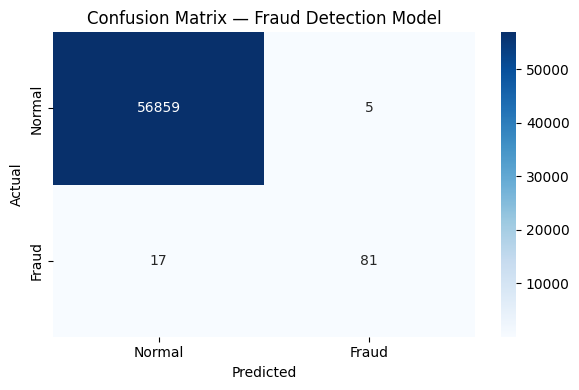

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Confusion Matrix — Fraud Detection Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

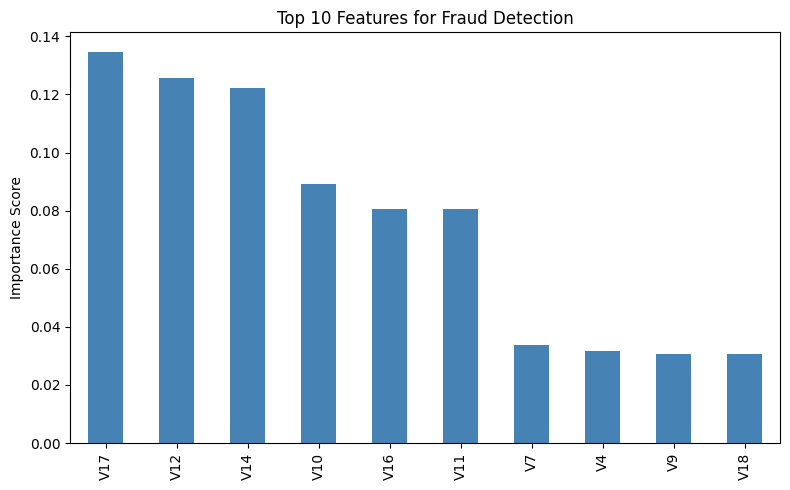

In [21]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top10.plot(kind='bar', color='steelblue')
plt.title('Top 10 Features for Fraud Detection')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()